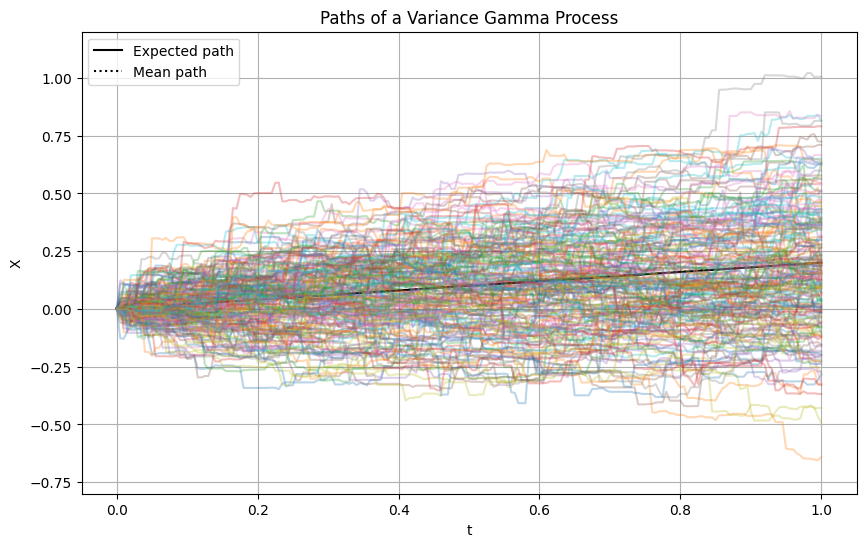

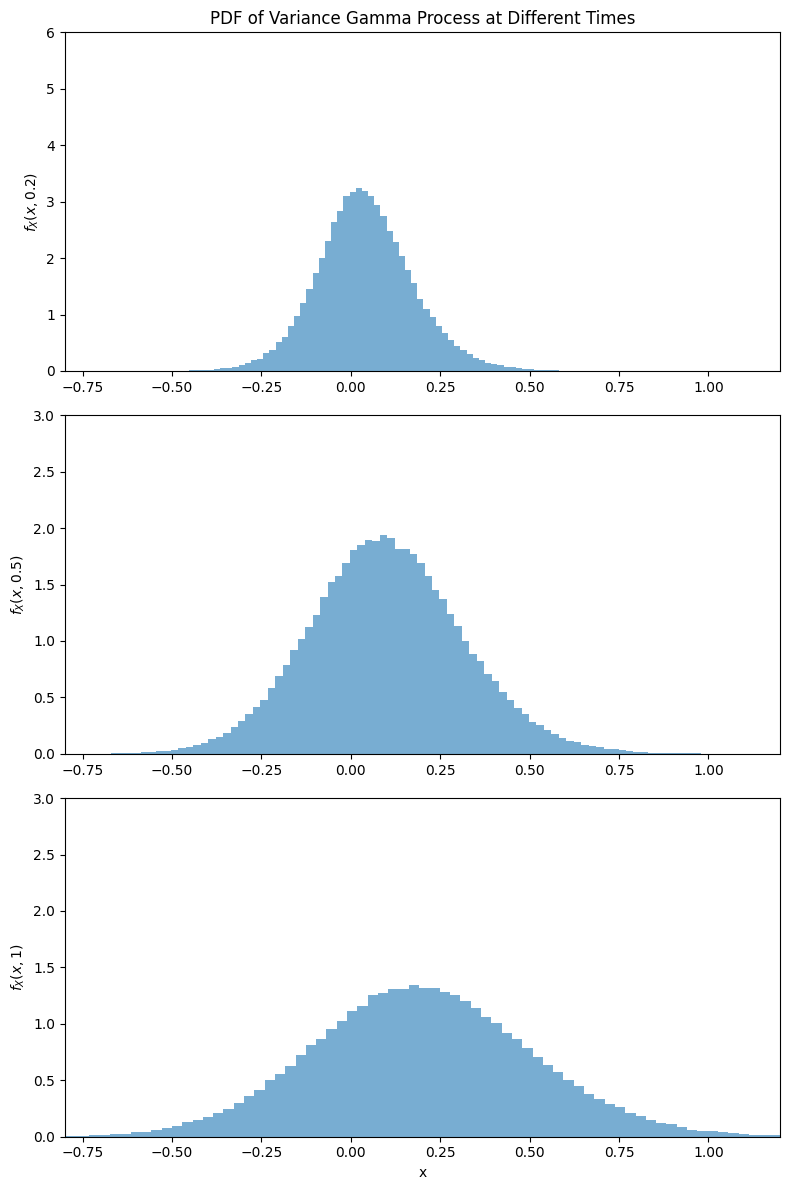

In [190]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Define parameters and time grid
npaths = 200000  # number of paths
T = 1  # time horizon
nsteps = 200  # number of time steps
dt = T / nsteps  # time step
t = np.linspace(0, T, nsteps + 1)  # observation times
mu, sigma = 0.2, 0.3  # model parameters of the ABM
kappa = 0.05  # scale parameter of the gamma process

# Monte Carlo simulation
# Compute the increments of the gamma process
dG = gamma.rvs(a=dt / kappa, scale=kappa, size=(nsteps, npaths))

# Compute the increments of the ABM on the gamma random clock
dX = mu * dG + sigma * np.random.randn(nsteps, npaths) * np.sqrt(dG)

# Accumulate the increments
X = np.vstack([np.zeros((1, npaths)), np.cumsum(dX, axis=0)])

# Expected, mean, and sample paths
plt.figure(figsize=(10, 6))
EX = mu * t  # expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(X, axis=1), ':k', label='Mean path')
plt.plot(t, X[:, ::1000], alpha=0.3)  # Sample paths
plt.xlabel('t')
plt.ylabel('X')
plt.ylim([-0.8, 1.2])
plt.legend()
plt.title('Paths of a Variance Gamma Process')
plt.grid()
plt.savefig('vgpaths.png')
plt.show()

# Probability density function at different times
plt.figure(figsize=(8, 12))

# Histogram and PDF for t = 0.2 (40th time step)
hist, bin_edges = np.histogram(X[40, :], bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.subplot(3, 1, 1)
plt.bar(bin_centers, hist, width=(bin_edges[1] - bin_edges[0]), alpha=0.6)
plt.ylabel('$f_X(x, 0.2)$')
plt.xlim([-0.8, 1.2])
plt.ylim([0, 6])
plt.title('PDF of Variance Gamma Process at Different Times')

# Histogram and PDF for t = 0.5 (100th time step)
hist, bin_edges = np.histogram(X[100, :], bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.subplot(3, 1, 2)
plt.bar(bin_centers, hist, width=(bin_edges[1] - bin_edges[0]), alpha=0.6)
plt.ylabel('$f_X(x, 0.5)$')
plt.xlim([-0.8, 1.2])
plt.ylim([0, 3])

# Histogram and PDF for t = 1.0 (final time step)
hist, bin_edges = np.histogram(X[-1, :], bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.subplot(3, 1, 3)
plt.bar(bin_centers, hist, width=(bin_edges[1] - bin_edges[0]), alpha=0.6)
plt.xlabel('x')
plt.ylabel('$f_X(x, 1)$')
plt.xlim([-0.8, 1.2])
plt.ylim([0, 3])

plt.tight_layout()
plt.savefig('vgdensities.png')
plt.show()